# Vulnerable record identification on Adult dataset
This notebook provides the code to identify most vulnerable records for the Adult dataset (https://archive.ics.uci.edu/dataset/2/adult). The list of most vulnerable records obtained from previous experiment is: `[39435, 36838, 6066, 1678, 27566, 43082, 16249, 14731, 5918, 35988]`. There is a difference of one in the top 10 between the paper results and the results in this notebook, while running the exact same code. This is considered as a small an insignificant difference, which likely not impact the others results significantly.

Note: this notebook has been copied and adapted from the original "Achilles' heels: Vulnerable Record Identification in Synthetic Data" repository: https://github.com/computationalprivacy/MIA-synthetic/tree/main.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# stdlib
import os
import sys

# third party
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Achille's Heel
os.chdir('..')
sys.path.append('./libs/MIA-synthetic-main')
from src.data_prep import read_data, read_metadata, discretize_dataset, normalize_cont_cols
from src.feature_extractors import fit_ohe, apply_ohe
from src.distance import compute_distances

## Load and preprocess the data
For reliable results, the Adult dataset must contains both training and test sets, and not contains undefined values. For more information about data extraction, please refer to the README of the `data` folder.

In [5]:
PATH_TO_METADATA = './data/adult_ah.json'
PATH_TO_DATA = './data/adult_header.csv'

meta_data_og, categorical_cols, continuous_cols = read_metadata(PATH_TO_METADATA)
df = read_data(PATH_TO_DATA, categorical_cols, continuous_cols)
df = df.replace('?', np.nan).dropna() # simply ignore the rows with missing values.
df = discretize_dataset(df, categorical_cols)
df = normalize_cont_cols(df, meta_data_og, df_aux = df, types = ('Float', 'Integer'))
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.301370,5,0.043350,9,0.800000,4,0,1,4,1,0.02174,0.0,0.397959,38,0
1,0.452055,4,0.047274,9,0.800000,2,3,0,4,1,0.00000,0.0,0.122449,38,0
2,0.287671,2,0.136877,11,0.533333,0,5,1,4,1,0.00000,0.0,0.397959,38,0
3,0.493151,2,0.149792,1,0.400000,2,5,0,2,1,0.00000,0.0,0.397959,38,0
4,0.150685,2,0.219998,9,0.800000,2,9,5,2,0,0.00000,0.0,0.397959,4,0


## Fit the one hot encoding for the categorical attributes

In [4]:
ohe, ohe_column_names = fit_ohe(df, categorical_cols, meta_data_og)
df_ohe = apply_ohe(df.copy(), ohe, categorical_cols, ohe_column_names, continuous_cols)
df_ohe

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_0,workclass_1,workclass_2,workclass_3,...,native-country_33,native-country_34,native-country_35,native-country_36,native-country_37,native-country_38,native-country_39,native-country_40,salary_0,salary_1
0,0.301370,0.043350,0.800000,0.021740,0.0,0.397959,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.452055,0.047274,0.800000,0.000000,0.0,0.122449,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.287671,0.136877,0.533333,0.000000,0.0,0.397959,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.493151,0.149792,0.400000,0.000000,0.0,0.397959,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.150685,0.219998,0.800000,0.000000,0.0,0.397959,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,0.219178,0.156895,0.800000,0.000000,0.0,0.397959,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
45218,0.301370,0.136723,0.800000,0.000000,0.0,0.357143,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
45219,0.287671,0.244762,0.800000,0.000000,0.0,0.500000,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
45220,0.369863,0.047666,0.800000,0.054551,0.0,0.397959,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## Compute the distances

We can now compute all distances between all records. This is an computationally expensive step, which might take up to 30 minutes.

In [ ]:
# get the right indices for the distance computation
all_columns = list(df_ohe.columns)
ohe_cat_indices = [all_columns.index(col) for col in ohe_column_names]
continous_indices = [all_columns.index(col) for col in continuous_cols]

records_paper = [39435, 1678, 35988, 36838, 6066, 27566, 16525, 43082, 5918, 16249]

# make sure to save the computed distances
ALL_DISTANCES = dict() 
N_TO_SAVE = 5
DISTANCE_METHOD = 'cosine'

df_ohe_values = df_ohe.values
targets = df_ohe.index

# for each record, we compute its distance with all datapoints
for i, target_id in tqdm(enumerate(targets), total=len(targets)):
    target_record = df_ohe.loc[target_id].values
    distances_target = compute_distances(record=target_record, values=df_ohe_values, 
                                         ohe_cat_indices=ohe_cat_indices, continous_indices=continous_indices,
                                         n_cat_cols=len(categorical_cols), n_cont_cols=len(continuous_cols),
                                         method = DISTANCE_METHOD)

    # let's sort it already
    ALL_DISTANCES[target_id] = np.sort(distances_target)[:N_TO_SAVE]

100%|██████████| 45222/45222 [32:20<00:00, 23.31it/s]  


## Identify the vulnerable records
    
We'll now compute, for each record, the mean distance to its 5 closest neighbors. The records for which this distance is the largest are considered the vulnerable ones. 

In [11]:
K_NEIGHBORS = 5

mean_distance_top_5 = dict()
for target_id in ALL_DISTANCES.keys():
    mean_distance_top_5[target_id] = np.mean(ALL_DISTANCES[target_id][:K_NEIGHBORS])

Text(0.5, 1.0, 'Distribution of mean distances of 5 closest points in sub df')

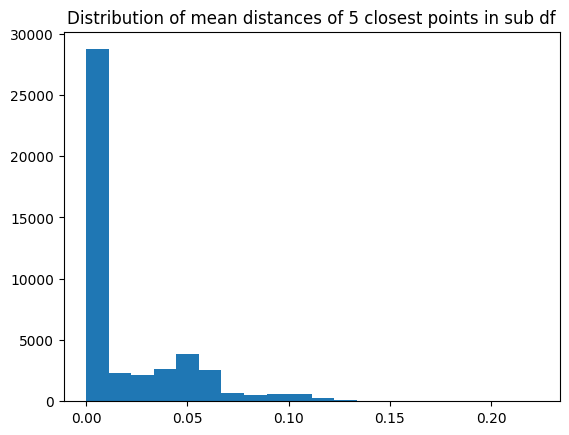

In [ ]:
plt.figure()
plt.hist(mean_distance_top_5.values(), bins = 20)
plt.title('Distribution of mean distances of 5 closest points')

We can see that only a small amount of samples has a large distance with their nearest neighbors. Let's identify them.

In [13]:
# Identify 10 vulnerable records by taking the 10 records with the greatest value
sorted_key_vals = sorted(mean_distance_top_5.items(), key=lambda x:x[1], reverse = True)
vulnerable_records = [k[0] for k in sorted_key_vals[:10]]
print(vulnerable_records)

[39435, 36838, 6066, 1678, 27566, 43082, 16249, 14731, 5918, 35988]


For completeness, we compare the indices we obtain with the ones claimed by the authors. We see that there's a difference of one in the top 10. After reflexion, it was declared as a non-problematic difference and the ones from our own experiments are kept.

In [ ]:
records_paper = [39435, 1678, 35988, 36838, 6066, 27566, 16525, 43082, 5918, 16249]
n_overlap = len(set(vulnerable_records).intersection(set(records_paper)))

print("Paper", np.sort(records_paper))
print("Found", np.sort(vulnerable_records))
print(f'Found {n_overlap} overlapping records and {10 - n_overlap} new record(s).')

Found 9 overlapping records and 1 new record(s).


# Random records for comparison

In [11]:
# select 10 random records not in the vulnerable records
vulnerable_records = [39435, 36838, 6066, 1678, 27566, 43082, 16249, 14731, 5918, 35988]
np_rng = np.random.default_rng(42)
random_idx = np_rng.integers(0, len(df), 10)
random_idx = [idx for idx in random_idx if idx not in vulnerable_records]
print(random_idx)
print(len(random_idx))

[4036, 34999, 29601, 19846, 19581, 38827, 3886, 31536, 9110, 4258]
10


## Analyze most vulnerable records in more details

### Full dataset

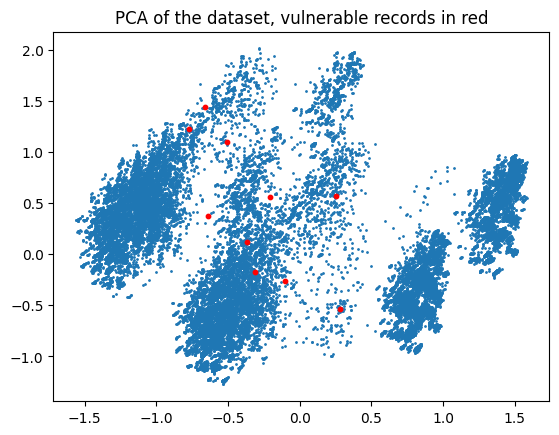

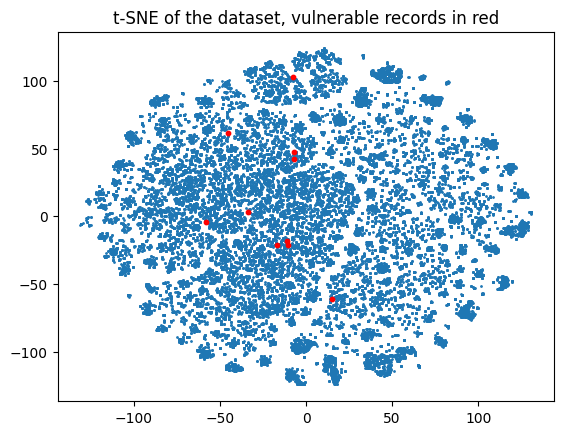

In [5]:
# perform pca analysis over the ohe dataset, in 2d
from sklearn.decomposition import PCA

vulnerable_records = [39435, 36838, 6066, 1678, 27566, 43082, 16249, 14731, 5918, 35988]

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_ohe.values)

# plot the vulnerable records in red
plt.figure()
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=1)
plt.scatter(pca_result[vulnerable_records, 0], pca_result[vulnerable_records, 1], s=10, c='r')
plt.title('PCA of the dataset, vulnerable records in red')

plt.show()

# perform the same analysis with t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
tsne_results = tsne.fit_transform(df_ohe.values)

plt.figure()
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], s=1)
plt.scatter(tsne_results[vulnerable_records, 0], tsne_results[vulnerable_records, 1], s=10, c='r')
plt.title('t-SNE of the dataset, vulnerable records in red')
plt.show()


### Continuous only

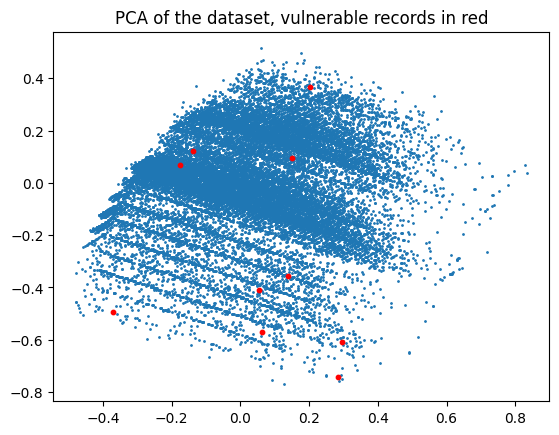

/Users/taapeco3/micromamba/envs/mia_synthetic/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 45222 samples in 0.021s...
[t-SNE] Computed neighbors for 45222 samples in 3.217s...
[t-SNE] Computed conditional probabilities for sample 1000 / 45222
[t-SNE] Computed conditional probabilities for sample 2000 / 45222
[t-SNE] Computed conditional probabilities for sample 3000 / 45222
[t-SNE] Computed conditional probabilities for sample 4000 / 45222
[t-SNE] Computed conditional probabilities for sample 5000 / 45222
[t-SNE] Computed conditional probabilities for sample 6000 / 45222
[t-SNE] Computed conditional probabilities for sample 7000 / 45222
[t-SNE] Computed conditional probabilities for sample 8000 / 45222
[t-SNE] Computed conditional probabilities for sample 9000 / 45222
[t-SNE] Computed conditional probabilities for sample 10000 / 45222
[t-SNE] Computed conditional probabilities for sample 11000 / 45222
[t-SNE] Computed conditional probabilities for sample 12000 / 45222
[t-SNE] Computed conditional probabilities for sa

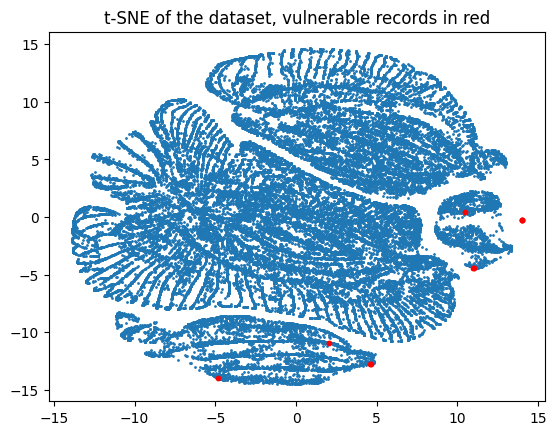

In [6]:
# perform pca analysis over the ohe dataset, in 2d
from sklearn.decomposition import PCA
df_ohe_cont = df_ohe[continuous_cols]

vulnerable_records = [39435, 36838, 6066, 1678, 27566, 43082, 16249, 14731, 5918, 35988]

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_ohe_cont.values)

# plot the vulnerable records in red
plt.figure()
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=1)
plt.scatter(pca_result[vulnerable_records, 0], pca_result[vulnerable_records, 1], s=10, c='r')
plt.title('PCA of the dataset, vulnerable records in red')

plt.show()

# perform the same analysis with t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)
tsne_results = tsne.fit_transform(df_ohe_cont.values)

plt.figure()
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], s=1)
plt.scatter(tsne_results[vulnerable_records, 0], tsne_results[vulnerable_records, 1], s=10, c='r')
plt.title('t-SNE of the dataset, vulnerable records in red')
plt.show()


### Categorical only

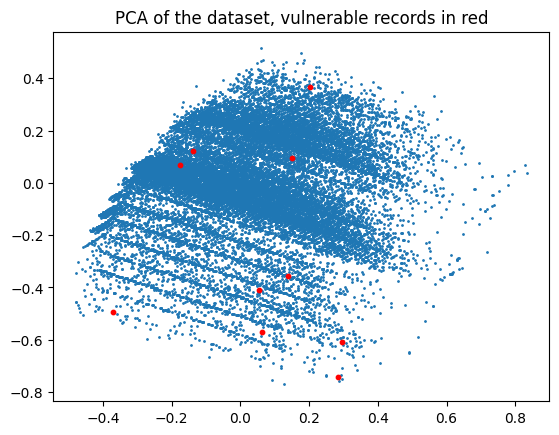

/Users/taapeco3/micromamba/envs/mia_synthetic/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 45222 samples in 0.017s...
[t-SNE] Computed neighbors for 45222 samples in 3.186s...
[t-SNE] Computed conditional probabilities for sample 1000 / 45222
[t-SNE] Computed conditional probabilities for sample 2000 / 45222
[t-SNE] Computed conditional probabilities for sample 3000 / 45222
[t-SNE] Computed conditional probabilities for sample 4000 / 45222
[t-SNE] Computed conditional probabilities for sample 5000 / 45222
[t-SNE] Computed conditional probabilities for sample 6000 / 45222
[t-SNE] Computed conditional probabilities for sample 7000 / 45222
[t-SNE] Computed conditional probabilities for sample 8000 / 45222
[t-SNE] Computed conditional probabilities for sample 9000 / 45222
[t-SNE] Computed conditional probabilities for sample 10000 / 45222
[t-SNE] Computed conditional probabilities for sample 11000 / 45222
[t-SNE] Computed conditional probabilities for sample 12000 / 45222
[t-SNE] Computed conditional probabilities for sa

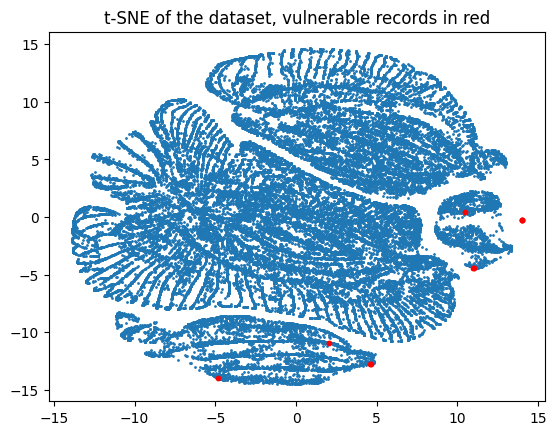

In [7]:
# perform pca analysis over the ohe dataset, in 2d
from sklearn.decomposition import PCA
df_ohe_cat = df_ohe[continuous_cols]

vulnerable_records = [39435, 36838, 6066, 1678, 27566, 43082, 16249, 14731, 5918, 35988]

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_ohe_cat.values)

# plot the vulnerable records in red
plt.figure()
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=1)
plt.scatter(pca_result[vulnerable_records, 0], pca_result[vulnerable_records, 1], s=10, c='r')
plt.title('PCA of the dataset, vulnerable records in red')

plt.show()

# perform the same analysis with t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)
tsne_results = tsne.fit_transform(df_ohe_cat.values)

plt.figure()
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], s=1)
plt.scatter(tsne_results[vulnerable_records, 0], tsne_results[vulnerable_records, 1], s=10, c='r')
plt.title('t-SNE of the dataset, vulnerable records in red')
plt.show()
